# Hedging — Pathwise Delta / Gamma and a Daily-Rebalanced Hedge

Risk sensitivities and a **daily-rebalanced delta hedge** for the swing option at the focal regime
($c=0.04$, $\gamma=2$), comparing three pricers throughout: **LSM** (full-state Least-Squares Monte
Carlo benchmark), **RL** (D4PG trained with the single-sample TD bootstrap, *no kernel*), and
**RL-kernel** (D4PG trained with the semi-analytical expected backup over the HHK transition kernel).

**Greeks — CRN bump-and-revalue.** $V(S_0)$ is revalued under the frozen policy on path bundles
started at bumped initial spots sharing one simulation seed; in HHK the seed-keyed draws are
independent of $S_0$, so the finite-difference noise cancels path-by-path. See `src/greeks.py`,
`tools/test_greeks.py`.

**Daily hedge.** At each decision date the per-path continuation Delta
$\Delta_t=\partial V_t/\partial S_t$ is obtained by bumping the prompt spot and re-rolling the
policy to maturity (the bump propagates through the OU factor in closed form,
$X_k\to X_k+\delta e^{-\alpha(t_k-t)}$). The pathwise delta anticipates the future, so it is
projected onto the date-$t$ state (Longstaff–Schwartz) to make the hedge ratio
$\mathcal F_t$-measurable. We hedge with the HHK forward to maturity; the discounted P&L increment
per contract is the martingale difference $\mathrm{DF}_{t+1}(F_{t+1}-F_t)$.

**Switching kernel / no-kernel.** The two RL variants are trained with **different canonical
configurations** (the kernel makes the TD target deterministic, so critic LR, exploration schedule,
depth, and gradient steps differ; both flag sets live in `tools/train_hedging_agents.py`). Each entry
in the `AGENTS` registry below is rebuilt from its own saved-run JSON, so adding, removing, or
swapping a variant is a one-line change.


In [1]:
import os, sys, json, warnings, contextlib, io, tempfile
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from src.greeks import (make_rl_price_fn, rl_dynamic_delta_hedge,
                        regression_forward_hedge, _load_actor_weights)
from src.simulate_hhk_spot import simulate_hhk_spot
from src.hedging_utils import compute_pnl_risk_metrics
from src.lsm_swing_pricer import fit_lsm_estimators, price_swing_option_lsm_oos
from tools.rebuild_results_v7 import build_agent, build_contract, build_hhk_params, dotdict

FIGS_DIR = os.path.abspath(os.path.join("..", "figs")); os.makedirs(FIGS_DIR, exist_ok=True)
RUNS_DIR = os.path.abspath(os.path.join("..", "runs"))
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

@contextlib.contextmanager
def quiet():
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        yield

# --- RL variant registry (focal c=0.04, gamma=2, seed 11, 32 768 episodes each) -------------
# Swap or add variants by editing run names; each agent is rebuilt from its own .json,
# so the per-variant training configuration is honoured automatically.
AGENTS = {
    "RL-kernel": "SwingOption_20_c0.04_gamma2_v64_32k_11",       # expected backup (v64)
    "RL":        "SwingOption_20_c0.04_gamma2_nokernel_32k_11",  # single-sample TD, no kernel
}
VCOL = {"RL-kernel": "#0b7285", "RL": "#e8590c", "LSM": "#54a24b"}
VMRK = {"RL-kernel": "o", "RL": "^", "LSM": "s"}

N_GRID  = 9          # S0 grid nodes for the revalued greeks
SEED    = 999        # common CRN/test seed for all three methods
N_RL    = 8192       # RL CRN paths for the greeks grid
N_HEDGE = 4096       # paths for the daily hedge (O(N_rights^2) re-rolls -> keep modest)
LSM_TRAIN, LSM_TEST = 16384, 8192
LSM_KW = dict(poly_degree=2, basis_type="chebyshev", state_mode="full",
              reg_type="none", reg_alpha=1e-6, n_actions=5)

agents, cfg_rows = {}, []
for label, run in AGENTS.items():
    with open(os.path.join(RUNS_DIR, f"{run}.json")) as fh:
        p = dotdict(json.load(fh))
    with quiet():
        a = build_agent(p); _load_actor_weights(a, os.path.join(RUNS_DIR, f"{run}.pth"))
    agents[label] = (a, p)
    cfg_rows.append({"variant": label, "run": run, "kernel": bool(int(p.use_expected_target or 0)),
                     "episodes": int(p.n_paths), "layers": int(p.actor_layers),
                     "squash": p.actor_output_activation, "lr_c": float(p.lr_c),
                     "noise": p.noise_schedule, "eval EMA": p.weight_averaging})

params   = agents["RL-kernel"][1]
contract = build_contract(params); hhk = build_hhk_params(params)
for label, (_, p) in agents.items():   # all variants must price the same contract
    assert (p.c_cost, p.gamma_cost, p.strike, p.n_rights) == \
           (params.c_cost, params.gamma_cost, params.strike, params.n_rights), label
S0, alpha, T = float(params.S0), float(params.alpha), float(contract.maturity)

print(f"Contract: S0={S0}, K={contract.strike}, n_rights={contract.n_rights}, "
      f"c={contract.c_cost}, gamma_c={contract.gamma_cost} | HHK alpha={alpha}")

cfg_df = pd.DataFrame(cfg_rows).set_index("variant")
# Shorten the run name: strip the common "SwingOption_20_c0.04_gamma2_" prefix
cfg_df["run"] = cfg_df["run"].str.replace("SwingOption_20_c0.04_gamma2_", "", regex=False)
display(cfg_df.style
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "th.row_heading, td.row_heading",
         "props": [("text-align", "left"), ("font-weight", "bold"), ("min-width", "80px")]},
        {"selector": "caption",
         "props": [("caption-side", "top"), ("font-size", "11px"),
                   ("text-align", "left"), ("padding-bottom", "4px")]},
    ])
    .set_caption("AGENTS registry — each variant is rebuilt from its saved-run JSON")
    .format({"episodes": "{:,}", "lr_c": "{:.4f}", "kernel": lambda v: "✓" if v else "✗"}))

Contract: S0=1.0, K=1.0, n_rights=22, c=0.04, gamma_c=2.0 | HHK alpha=12.0


,run,kernel,episodes,layers,squash,lr_c,noise,eval EMA
variant,,,,,,,,
RL-kernel,v64_32k_11,✓,"32,768",3,beta_sigmoid_1.5,0.0006,linear,ema
RL,nokernel_32k_11,✗,"32,768",2,beta_sigmoid_3.0,0.0003,hyperbolic,off


## 1. PV, Delta, Gamma over a 9-point $S_0$ grid — revalued

Grid spans $[0.5\,S_0,\,2.0\,S_0]$. PV is **revalued** at each node — RL via CRN policy
revaluation, LSM by refitting and pricing out-of-sample at that spot — and Delta/Gamma are central
finite differences of the revalued PV grid. All three methods share the test seed.


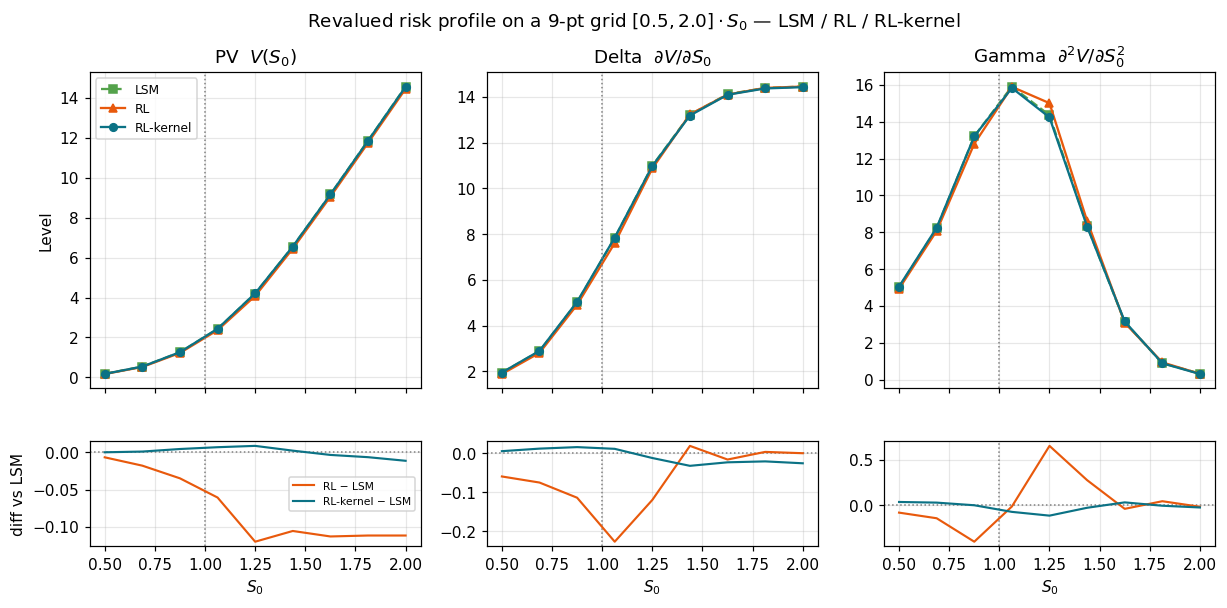

,S0,PV LSM,PV RL,PV RL-kernel,ΔPV RL,ΔPV RL-kernel,Δ LSM,Δ RL,Δ RL-kernel,Γ LSM,Γ RL,Γ RL-kernel
0,0.500,0.179,0.172,0.179,-0.006,+0.000,1.942,1.883,1.948,5.021,4.938,5.056
1,0.688,0.543,0.525,0.544,-0.018,+0.001,2.884,2.809,2.896,8.221,8.076,8.249
2,0.875,1.260,1.226,1.265,-0.035,+0.005,5.025,4.911,5.041,13.214,12.809,13.212
3,1.062,2.428,2.367,2.435,-0.061,+0.007,7.839,7.612,7.850,15.916,15.901,15.842
4,1.250,4.200,4.080,4.209,-0.120,+0.009,10.994,10.874,10.982,14.358,15.014,14.241
5,1.438,6.550,6.445,6.553,-0.106,+0.002,13.223,13.242,13.191,8.342,8.619,8.313
6,1.625,9.159,9.046,9.155,-0.113,-0.003,14.122,14.106,14.099,3.126,3.085,3.157
7,1.812,11.846,11.735,11.840,-0.112,-0.006,14.396,14.399,14.375,0.894,0.937,0.887
8,2.000,14.557,14.445,14.546,-0.112,-0.011,14.457,14.457,14.432,0.330,0.312,0.304


In [2]:
grid = np.linspace(0.5 * S0, 2.0 * S0, N_GRID)

# --- RL variants: revalue PV at each grid node (shared CRN seed) ---
V = {}
with quiet():
    for label, (agent, _) in agents.items():
        fn = make_rl_price_fn(agent, contract, hhk, N_RL)
        V[label] = np.array([fn(s, SEED).mean() for s in grid])

# --- LSM: refit + OOS price at each grid node ---
def lsm_price_at(s0_value, csv_path=None):
    base = {k: v for k, v in hhk.items() if k != "S0"}
    train = tuple(np.asarray(a, np.float64) for a in
                  simulate_hhk_spot(S0=s0_value, n_paths=LSM_TRAIN, seed=998, stratify=True, **base))
    test = tuple(np.asarray(a, np.float64) for a in
                 simulate_hhk_spot(S0=s0_value, n_paths=LSM_TEST, seed=SEED, stratify=True, **base))
    est = fit_lsm_estimators(contract=contract, dataset=train, **LSM_KW)
    price, _ = price_swing_option_lsm_oos(contract=contract, dataset=test, estimators=est,
                                          seed=999, csv_path=csv_path, _print_results=False)
    return float(price)

with quiet():
    V["LSM"] = np.array([lsm_price_at(s) for s in grid])

def central_dd(grid, v):
    d1 = np.gradient(v, grid)
    return d1, np.gradient(d1, grid)

methods = ["LSM", "RL", "RL-kernel"]
D = {m: central_dd(grid, V[m])[0] for m in methods}
G = {m: central_dd(grid, V[m])[1] for m in methods}

fig, ax = plt.subplots(2, 3, figsize=(13.2, 5.6), sharex="col",
                       gridspec_kw={"height_ratios": [3.0, 1.0], "hspace": 0.25})
panels = [(V, "PV  $V(S_0)$"), (D, "Delta  $\\partial V/\\partial S_0$"),
          (G, "Gamma  $\\partial^2 V/\\partial S_0^2$")]
for col, (Y, ttl) in enumerate(panels):
    top, bot = ax[0, col], ax[1, col]
    for m in methods:
        ls = "--" if m == "LSM" else "-"
        top.plot(grid, Y[m], VMRK[m] + ls, color=VCOL[m], ms=5, label=m)
    top.axvline(S0, color="grey", ls=":", lw=1); top.set_title(ttl)
    bot.axhline(0, color="grey", lw=1, ls=":"); bot.axvline(S0, color="grey", ls=":", lw=1)
    for m in ["RL", "RL-kernel"]:
        bot.plot(grid, Y[m] - Y["LSM"], color=VCOL[m], lw=1.4, label=f"{m} − LSM")
    bot.set_xlabel("$S_0$")
ax[0, 0].legend(fontsize=8); ax[1, 0].legend(fontsize=7)
ax[0, 0].set_ylabel("Level"); ax[1, 0].set_ylabel("diff vs LSM")
fig.suptitle(f"Revalued risk profile on a {N_GRID}-pt grid $[0.5, 2.0]\\cdot S_0$ — LSM / RL / RL-kernel", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(os.path.join(FIGS_DIR, "hedging_greeks_grid_rl_lsm.png"), bbox_inches="tight")
plt.show()

# --- Styled PV / Delta / Gamma table with colour-coded RL-vs-LSM differences ---
tbl = {"S0": grid.round(3)}
for m in methods:
    tbl[f"PV {m}"] = V[m].round(3)
for m in ["RL", "RL-kernel"]:
    tbl[f"ΔPV {m}"] = (V[m] - V["LSM"]).round(3)
for m in methods:
    tbl[f"Δ {m}"] = D[m].round(3)
for m in methods:
    tbl[f"Γ {m}"] = G[m].round(3)

df_tbl = pd.DataFrame(tbl)
diff_cols = ["ΔPV RL", "ΔPV RL-kernel"]
V_diff = float(df_tbl[diff_cols].abs().max().max())

display(df_tbl.style
    .background_gradient(cmap="RdYlGn", subset=diff_cols, vmin=-V_diff, vmax=V_diff)
    .format({c: "{:+.3f}" for c in diff_cols} |
            {c: "{:.3f}" for c in df_tbl.columns if c not in diff_cols})
    .set_caption("PV, Delta (∂V/∂S₀), Gamma (∂²V/∂S₀²) on the 9-point revaluation grid. "
                 "ΔPV = RL − LSM (green = above, red = below).")
    .set_properties(**{"text-align": "center"})
    .set_table_styles([
        {"selector": "caption",
         "props": [("caption-side", "top"), ("font-size", "11px"),
                   ("text-align", "left"), ("padding-bottom", "6px")]},
        {"selector": "th",
         "props": [("text-align", "center")]},
    ]))

**RL-kernel reproduces the LSM value function** to within $\pm0.01$ PV units ($\lesssim0.5\%$)
over the entire $[0.5,2.0]\cdot S_0$ range, with Delta and Gamma profiles that coincide with the
benchmark. **RL (no kernel)** prices systematically below both — the shortfall is largest near the
money ($\approx-2.5\%$ at $S_0\approx1.06$) — yet its Greeks stay close to the common profile: the
no-kernel deficit is an exercise-quality effect on value, not a different risk profile.


## 2. Daily-rebalanced delta hedge — both RL policies

Per-date continuation Delta by spot-bump-and-re-roll, conditioned on the date-$t$ state
(Longstaff–Schwartz projection), hedged with the HHK forward to maturity. The same procedure runs on
each RL variant's own policy and cashflows.


RL-kernel  PV=1.9819 | unhedged std 2.5963 -> hedged std 1.4025 (mean +0.0050; var reduction 70.8%)
RL         PV=1.9221 | unhedged std 2.6039 -> hedged std 1.4141 (mean +0.0073; var reduction 70.5%)


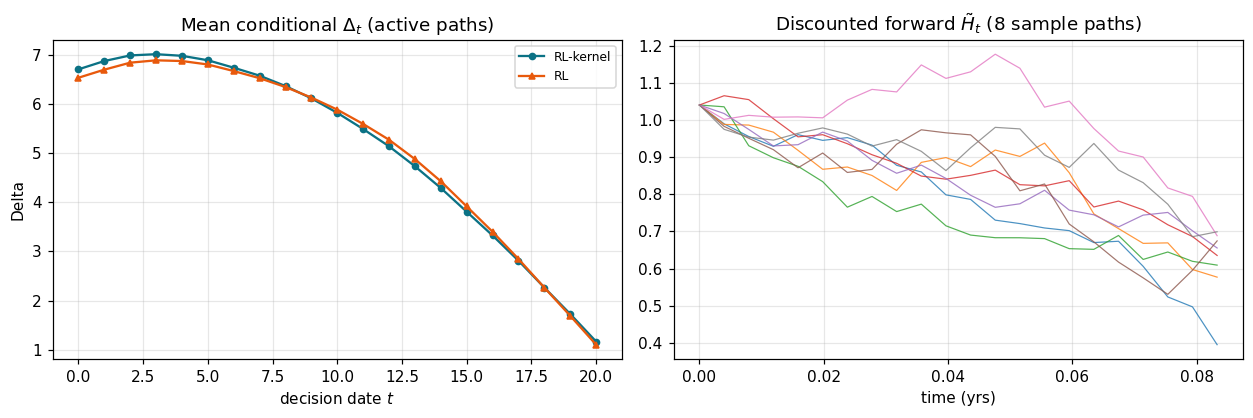

In [3]:
H = {}
with quiet():
    for label, (agent, _) in agents.items():
        H[label] = rl_dynamic_delta_hedge(agent, contract, hhk, S0, n_paths=N_HEDGE, seed=SEED, h=0.01)

dates = np.arange(contract.n_rights - 1)
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.9))
for label, h in H.items():
    m_u, m_h = compute_pnl_risk_metrics(h.pnl_unhedged), compute_pnl_risk_metrics(h.pnl_hedged)
    print(f"{label:10s} PV={h.pv.mean():.4f} | unhedged std {m_u.std_pnl:.4f} -> hedged std {m_h.std_pnl:.4f} "
          f"(mean {m_h.mean_pnl:+.4f}; var reduction {100*(1-m_h.variance_pnl/m_u.variance_pnl):.1f}%)")
    mean_delta = np.array([h.delta_t[h.delta_t[:, t] != 0, t].mean()
                           if (h.delta_t[:, t] != 0).any() else np.nan for t in dates])
    ax[0].plot(dates, mean_delta, VMRK[label] + "-", color=VCOL[label], ms=4, label=label)
ax[0].set(title="Mean conditional $\\Delta_t$ (active paths)", xlabel="decision date $t$", ylabel="Delta")
ax[0].legend(fontsize=8)
ax[1].plot(H["RL-kernel"].t_grid, H["RL-kernel"].Htilde[:8].T, lw=0.8, alpha=0.8)
ax[1].set(title="Discounted forward $\\tilde H_t$ (8 sample paths)", xlabel="time (yrs)")
fig.tight_layout(); fig.savefig(os.path.join(FIGS_DIR, "hedging_daily_mechanics.png"), bbox_inches="tight")
plt.show()


The hedged P&L mean is $\approx 0$ for both policies — the forward is a fair martingale and the
hedge ratio is $\mathcal F_t$-measurable, so the hedge is non-anticipating — while the variance drops
by $\approx$70%. Hedge quality is essentially identical across the two RL variants: the kernel's
contribution is pricing accuracy, not hedgeability.


## 3. A common hedge for all three pricers — regression delta

To compare RL and LSM on equal footing we hedge **all three** with the same **regression
(Longstaff–Schwartz) delta**: at each date the realised continuation value is regressed on the
date-$t$ state and differentiated in spot. This single $\mathcal F_t$-measurable estimator runs
identically on RL and LSM cashflows. For the RL policies we additionally keep the refined
continuation-bump hedge from §2, which the differentiable policies make possible.


In [4]:
# --- LSM per-path cashflows + states via the OOS parquet ---
base = {k: v for k, v in hhk.items() if k != "S0"}
with quiet():
    t_grid, S_l, X_l, Y_l = simulate_hhk_spot(S0=S0, n_paths=LSM_TEST, seed=SEED, stratify=True, **base)
    train = tuple(np.asarray(a, np.float64) for a in
                  simulate_hhk_spot(S0=S0, n_paths=LSM_TRAIN, seed=998, stratify=True, **base))
    est = fit_lsm_estimators(contract=contract, dataset=train, **LSM_KW)
    tmp = os.path.join(tempfile.gettempdir(), "lsm_hedge_paths.parquet")
    lsm_price, _ = price_swing_option_lsm_oos(contract=contract,
        dataset=tuple(np.asarray(a, np.float64) for a in (t_grid, S_l, X_l, Y_l)),
        estimators=est, seed=999, csv_path=tmp, _print_results=False)

N = contract.n_rights
ldf = pd.read_parquet(tmp)
pcol = "payoff_net" if "payoff_net" in ldf.columns else "payoff"
pth, stp = ldf["path"].to_numpy(), ldf["time_step"].to_numpy()
cf_lsm = np.zeros((LSM_TEST, N)); qb_lsm = np.zeros((LSM_TEST, N))
cf_lsm[pth, stp] = np.power(contract.discount_factor, stp) * ldf[pcol].to_numpy()
qb_lsm[pth, stp] = ldf["q_exercised_so_far"].to_numpy()
print(f"LSM price (scalar) {lsm_price:.4f}  vs  per-path pv mean {cf_lsm.sum(axis=1).mean():.4f}")

# --- the same regression-delta forward hedge for all three cashflow sets ---
reg = {"LSM": regression_forward_hedge(cf_lsm, S_l, X_l, Y_l, qb_lsm, t_grid, contract, hhk)}
for label, h in H.items():
    reg[label] = regression_forward_hedge(h.cf, h.spot, h.X, h.Y, h.q_before, h.t_grid, contract, hhk)

rows = {}
for label in ["LSM", "RL", "RL-kernel"]:
    rows[f"{label} unhedged"] = compute_pnl_risk_metrics(reg[label]["pnl_unhedged"]).as_dict()
    rows[f"{label} regression-hedged"] = compute_pnl_risk_metrics(reg[label]["pnl_hedged"]).as_dict()
for label in H:
    rows[f"{label} continuation-hedged"] = compute_pnl_risk_metrics(H[label].pnl_hedged).as_dict()
risk = pd.DataFrame(rows).T
risk["std reduction %"] = [100*(1 - r.std_pnl / risk.loc[f"{k.split(' ')[0]} unhedged", "std_pnl"])
                           if "unhedged" not in k else np.nan for k, r in risk.iterrows()]

# Styled table: colour the decision-relevant columns
highlight_cols = ["std_pnl", "cvar_pnl_95", "std reduction %"]
sty = (risk.round(4).style
       .background_gradient(cmap="RdYlGn_r", subset=["std_pnl"], vmin=0)
       .background_gradient(cmap="RdYlGn", subset=["cvar_pnl_95"])
       .background_gradient(cmap="Greens", subset=["std reduction %"], vmin=0, vmax=50)
       .format({c: "{:.4f}" for c in risk.columns if c != "std reduction %"})
       .format({"std reduction %": "{:.1f}"}, na_rep="—")
       .set_properties(**{"text-align": "center"})
       .set_caption("Seller P&L risk metrics — lower std / more negative ES = more risk; "
                    "higher std-reduction % = better hedge.")
       .set_table_styles([
           {"selector": "caption",
            "props": [("caption-side", "top"), ("font-size", "11px"),
                      ("text-align", "left"), ("padding-bottom", "6px")]},
       ]))
display(sty)

LSM price (scalar) 1.9828  vs  per-path pv mean 1.9828


,mean_pnl,variance_pnl,std_pnl,var_pnl_95,cvar_pnl_95,min_pnl,max_pnl,std reduction %
LSM unhedged,-0.000000,6.176500,2.485300,-5.093200,-7.013900,-18.991100,1.982800,—
LSM regression-hedged,0.005400,2.200900,1.483500,-2.509000,-4.333600,-18.780500,4.677800,40.3
RL unhedged,0.000000,6.780400,2.603900,-5.059600,-7.212400,-51.692700,1.922100,—
RL regression-hedged,0.002100,2.821800,1.679800,-2.499700,-4.404800,-50.084800,3.182100,35.5
RL-kernel unhedged,-0.000000,6.740600,2.596300,-4.995900,-7.159400,-51.727600,1.981900,—
RL-kernel regression-hedged,-0.001300,2.788200,1.669800,-2.456900,-4.431600,-49.967300,2.701500,35.7
RL-kernel continuation-hedged,0.005000,1.967000,1.402500,-1.504000,-3.828900,-49.755400,5.086100,46.0
RL continuation-hedged,0.007300,1.999700,1.414100,-1.534000,-3.852700,-49.795100,5.282400,45.7


## 4. Final P&L distributions with VaR & ES

95% **VaR** (5th percentile of seller P&L) and **ES** (mean of the 5% left tail) as vertical lines.
Left: the policy-specific continuation-bump hedge (RL vs RL-kernel). Right: the common
regression-delta hedge across all three pricers.


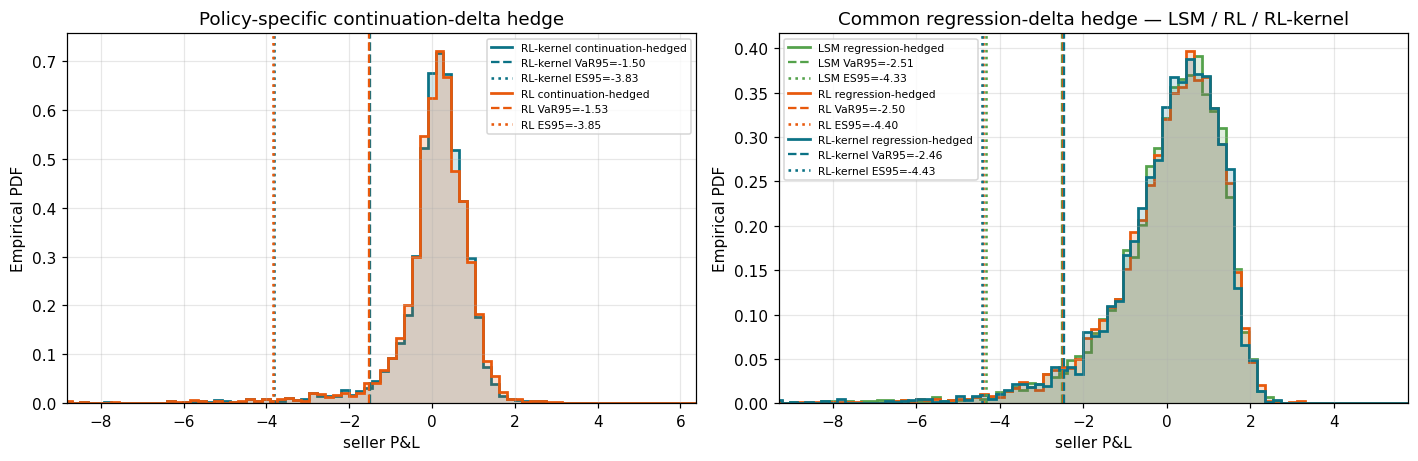

In [5]:
PLOT_LEFT_TAIL_CLIP_Q = 0.002  # display-only x-axis clip at the pooled left-tail quantile
PLOT_MIN_BINS, PLOT_MAX_BINS = 40, 300

def var_es_lines(ax, pnl, color, label):
    m = compute_pnl_risk_metrics(pnl, alpha=0.95)
    ax.axvline(m.var_pnl_95, color=color, ls="--", lw=1.5, label=f"{label} VaR95={m.var_pnl_95:.2f}")
    ax.axvline(m.cvar_pnl_95, color=color, ls=":",  lw=1.7, label=f"{label} ES95={m.cvar_pnl_95:.2f}")

def pooled_pdf_edges(*samples, min_bins=PLOT_MIN_BINS, max_bins=PLOT_MAX_BINS):
    pooled = np.concatenate(samples)
    q25, q75 = np.quantile(pooled, [0.25, 0.75])
    span, iqr = pooled.max() - pooled.min(), q75 - q25
    if span <= 0 or iqr <= 0:
        n_bins = min_bins
    else:
        width = 2.0 * iqr * pooled.size ** (-1.0 / 3.0)
        n_bins = min_bins if width <= 0 else int(np.ceil(span / width))
    n_bins = int(np.clip(n_bins, min_bins, max_bins))
    pad = 0.02 * span if span > 0 else 1.0
    return np.linspace(pooled.min() - pad, pooled.max() + pad, n_bins + 1)

def plot_empirical_pdf(ax, samples, edges, color, label, fill_alpha=0.18):
    hist, _ = np.histogram(samples, bins=edges, density=True)
    ax.stairs(hist, edges, color=color, lw=1.8, label=label)
    ax.stairs(hist, edges, baseline=0.0, fill=True, color=color, alpha=fill_alpha)

# Empirical PDFs (not KDE): these P&L laws have hard support and visible atoms.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))

s0 = {k: H[k].pnl_hedged for k in H}
edges0 = pooled_pdf_edges(*s0.values())
for k, v in s0.items():
    plot_empirical_pdf(ax[0], v, edges0, VCOL[k], f"{k} continuation-hedged")
    var_es_lines(ax[0], v, VCOL[k], k)
ax[0].set_xlim(np.quantile(np.concatenate(list(s0.values())), PLOT_LEFT_TAIL_CLIP_Q), edges0[-1])
ax[0].set(title="Policy-specific continuation-delta hedge", xlabel="seller P&L", ylabel="Empirical PDF")
ax[0].legend(fontsize=7)

s1 = {k: reg[k]["pnl_hedged"] for k in ["LSM", "RL", "RL-kernel"]}
edges1 = pooled_pdf_edges(*s1.values())
for k, v in s1.items():
    plot_empirical_pdf(ax[1], v, edges1, VCOL[k], f"{k} regression-hedged")
    var_es_lines(ax[1], v, VCOL[k], k)
ax[1].set_xlim(np.quantile(np.concatenate(list(s1.values())), PLOT_LEFT_TAIL_CLIP_Q), edges1[-1])
ax[1].set(title="Common regression-delta hedge — LSM / RL / RL-kernel", xlabel="seller P&L", ylabel="Empirical PDF")
ax[1].legend(fontsize=7)

fig.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, "hedging_pnl_var_es.png"), bbox_inches="tight")
plt.show()


## 5. Takeaways

- **Pricing across spot (§1).** RL-kernel matches the LSM benchmark over the full
  $[0.5,2.0]\cdot S_0$ grid (PV within $\pm0.01$; Delta/Gamma coincide). RL without the kernel sits
  below both everywhere, worst near the money ($\approx-2.5\%$) — consistent with the pricing gap
  quantified in Validation 3.
- **The daily hedge works (§2).** The conditioned continuation-Delta forward hedge yields
  $\approx$0-mean seller P&L with $\approx$70% variance reduction for both RL policies; the hedge
  ratio is $\mathcal F_t$-measurable.
- **A common yardstick (§3–4).** Under the identical regression-delta hedge, all three pricers cut
  P&L std by 35–40% with nearly identical VaR/ES — hedge effectiveness does not separate them. The
  continuation-bump hedge, available only for the differentiable RL policies, does better:
  $\approx$46% std reduction and the tightest tail (ES95 $\approx-3.8$ vs $-4.3$/$-4.4$).
- **Where each method earns its place.** The kernel buys value-function accuracy (LSM-parity
  pricing); the differentiable policy buys an exact per-state continuation delta that the LSM
  capacity-DP cannot provide (it falls back on the regression delta). A DP-consistent LSM delta
  surface is a natural extension.
